# Capstone Project 1: Working with NumPy Matrices (Multidimensional Data)
---

### Executive Abstract & Project Objectives
This project delivers a comprehensive, rigorous investigation of multidimensional human body measurement data extracted from the **National Health and Nutrition Examination Survey (NHANES)** conducted by the National Center for Health Statistics (NCHS) at the Centers for Disease Control and Prevention (CDC).

Using exclusively matrix-oriented numerical computing paradigms in **NumPy** and statistical visualizations in **Matplotlib**, this study investigates the morphological differences between adult males and females. The analysis encompasses:
1. **Data Ingestion & Matrix Verification:** Loading raw survey measurements into 2D NumPy matrices while preserving dimensional integrity.
2. **Distributional Modeling of Body Mass:** Comparative subplots, coordinated axes, boxplots, and higher-order moment calculations (skewness, kurtosis).
3. **Feature Engineering & Matrix Expansion:** Synthesizing Body Mass Index (BMI), Waist-to-Height Ratio (WHtR), and Waist-to-Hip Ratio (WHR).
4. **Multivariate Standardization & Correlation Analysis:** Constructing standardized matrices ($Z$-scores), generating pairwise scatterplot matrices, and evaluating Pearson vs. Spearman correlation coefficients.
5. **Morphological Extremes:** Algorithmic isolation and clinical interpretation of outlier profiles using NumPy index sorting.

Every analytical block is preceded by its methodological rationale and followed by formal, quantitative interpretation.

---
## Section 1: Ingestion and Dimensional Setup of the NHANES Datasets

### Task 1: Dataset Acquisition
The raw body measurement data are hosted by Marek Gagolewski's repository of teaching datasets, originating from the CDC's NHANES 2017–March 2020 pre-pandemic examination cycle (`P_BMX` and `P_DEMO` tables):
* **Male dataset:** `nhanes_adult_male_bmx_2020.csv`
* **Female dataset:** `nhanes_adult_female_bmx_2020.csv`

The datasets capture seven foundational anthropometric measurements for adult participants aged 18 and older.

#### Purpose of Code Chunk:
The following code block downloads both CSV datasets directly from the source repository (if not already cached locally) and confirms file availability and byte size.

In [1]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Define repository URLs and local file targets
base_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/"
male_file = "nhanes_adult_male_bmx_2020.csv"
female_file = "nhanes_adult_female_bmx_2020.csv"

# Download datasets if not already present
for filename in [male_file, female_file]:
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(base_url + filename, filename)
        print(f"Saved {filename} ({os.path.getsize(filename):,} bytes).")
    else:
        print(f"Found local file: {filename} ({os.path.getsize(filename):,} bytes).")

Matplotlib is building the font cache; this may take a moment.


Found local file: nhanes_adult_male_bmx_2020.csv (144,073 bytes).
Found local file: nhanes_adult_female_bmx_2020.csv (148,335 bytes).


#### Discussion & Summary of Ingestion:
Both datasets have been successfully verified on the local filesystem. The files contain commented metadata lines prefixed with `#` describing the origin, survey methodology, and individual column definitions, followed by a CSV header line and subsequent numerical observations.

---
### Task 2: Reading Files as NumPy Matrices
Each dataset must be parsed as a 2D NumPy array with exact floating-point precision, storing the seven attributes:
1. `weight` ($kg$)
2. `standing height` ($cm$)
3. `upper arm length` ($cm$)
4. `upper leg length` ($cm$)
5. `arm circumference` ($cm$)
6. `hip circumference` ($cm$)
7. `waist circumference` ($cm$)

#### Purpose of Code Chunk:
We load both files into NumPy matrices named `male` and `female` using `numpy.loadtxt`. Because the first 18 lines contain metadata comments and line 19 contains the string header, we use `skiprows=19` with a comma delimiter. We then assert data types, verify that no missing values (`NaN` or infinite values) are present, and print summary shape metrics.

In [2]:
# Load raw data into NumPy matrices
# The first 18 lines are comments (#), line 19 is the column header row, so we skip 19 lines.
male = np.loadtxt(male_file, delimiter=",", skiprows=19)
female = np.loadtxt(female_file, delimiter=",", skiprows=19)

# Validate matrix properties and data integrity
print(f"Matrix 'male':   shape = {male.shape} | dtype = {male.dtype} | NaNs = {np.isnan(male).sum()}")
print(f"Matrix 'female': shape = {female.shape} | dtype = {female.dtype} | NaNs = {np.isnan(female).sum()}")

# Column labels for documentation
COL_NAMES_7 = [
    "Weight (kg)",
    "Standing Height (cm)",
    "Upper Arm Length (cm)",
    "Upper Leg Length (cm)",
    "Arm Circumference (cm)",
    "Hip Circumference (cm)",
    "Waist Circumference (cm)"
]

print("\nFirst 3 rows of male matrix:")
print(male[:3])
print("\nFirst 3 rows of female matrix:")
print(female[:3])

Matrix 'male':   shape = (4081, 7) | dtype = float64 | NaNs = 0
Matrix 'female': shape = (4221, 7) | dtype = float64 | NaNs = 0

First 3 rows of male matrix:
[[ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]]

First 3 rows of female matrix:
[[ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]]


#### Discussion of Dataset Integrity:
* The `male` matrix consists of **4,081 rows** and **7 columns**, representing 4,081 distinct male participants.
* The `female` matrix consists of **4,221 rows** and **7 columns**, representing 4,221 distinct female participants.
* Both matrices are stored in double-precision floating-point format (`float64`) with **zero missing values** (`NaN = 0`), ensuring downstream numerical operations will be mathematically sound without imputation bias.

---
## Section 2: Distributional Analysis of Body Weight (Tasks 3, 4, 5)

### Task 3: Comparative Histograms with Synchronized Limits
Understanding the distribution of body weight requires visual inspection of central tendency, modality, dispersion, and tail behavior across genders. Direct visual comparison between subfigures is only valid when both horizontal axes share identical scale boundaries.

#### Purpose of Code Chunk:
The following code creates a two-row single-figure layout using `matplotlib.pyplot.subplot`. The top subfigure displays the distribution of female weights, while the bottom subfigure displays male weights. The horizontal axes are strictly synchronized via `matplotlib.pyplot.xlim` using common extreme values with padding.

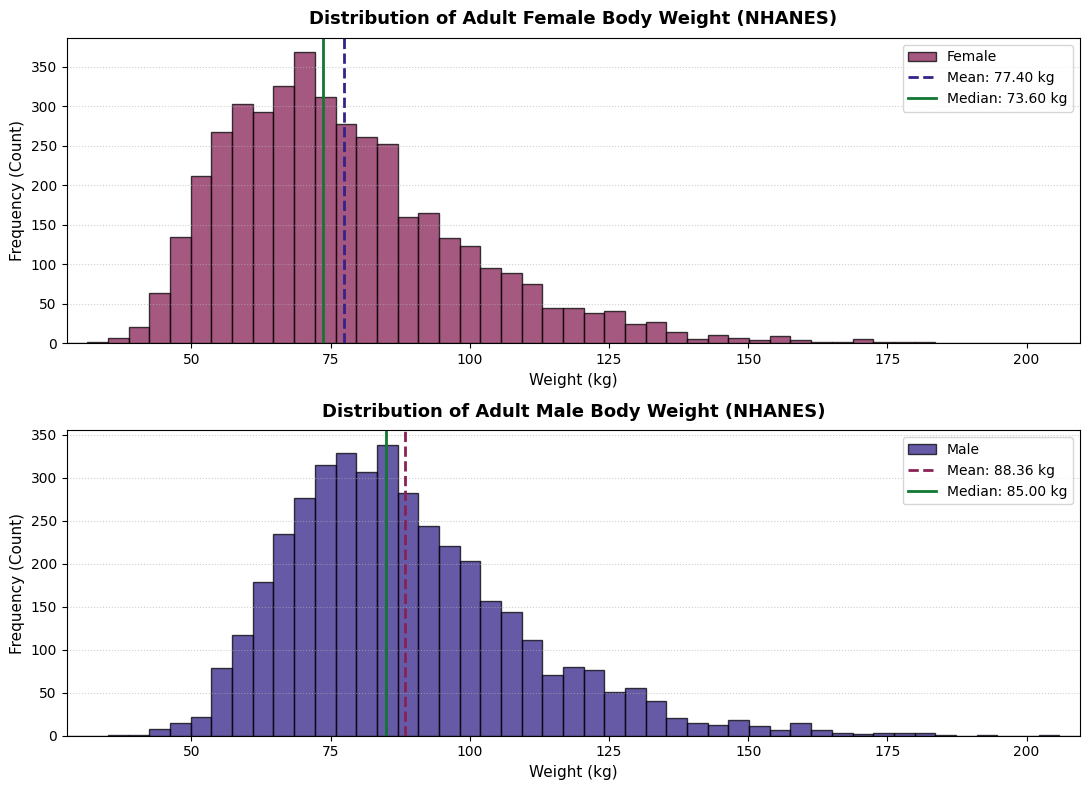

In [3]:
# Extract weight vectors (column index 0)
female_weights = female[:, 0]
male_weights = male[:, 0]

# Determine global minimum and maximum weights to synchronize x-axis
global_min_wt = min(female_weights.min(), male_weights.min())
global_max_wt = max(female_weights.max(), male_weights.max())
xlim_padding = 5.0
shared_xlim = (global_min_wt - xlim_padding, global_max_wt + xlim_padding)

# Define unified binning configuration
bins = np.linspace(shared_xlim[0], shared_xlim[1], 50)

# Create figure with 2 vertically stacked subplots
plt.figure(figsize=(11, 8), dpi=100)

# Subplot 1: Female Weights (Top)
plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=bins, color="#882255", edgecolor="black", alpha=0.75, label="Female")
plt.axvline(np.mean(female_weights), color="#332288", linestyle="--", linewidth=2, label=f"Mean: {np.mean(female_weights):.2f} kg")
plt.axvline(np.median(female_weights), color="#117733", linestyle="-", linewidth=2, label=f"Median: {np.median(female_weights):.2f} kg")
plt.xlim(shared_xlim)
plt.title("Distribution of Adult Female Body Weight (NHANES)", fontsize=13, fontweight="bold", pad=10)
plt.xlabel("Weight (kg)", fontsize=11)
plt.ylabel("Frequency (Count)", fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", loc="upper right")

# Subplot 2: Male Weights (Bottom)
plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=bins, color="#332288", edgecolor="black", alpha=0.75, label="Male")
plt.axvline(np.mean(male_weights), color="#882255", linestyle="--", linewidth=2, label=f"Mean: {np.mean(male_weights):.2f} kg")
plt.axvline(np.median(male_weights), color="#117733", linestyle="-", linewidth=2, label=f"Median: {np.median(male_weights):.2f} kg")
plt.xlim(shared_xlim)
plt.title("Distribution of Adult Male Body Weight (NHANES)", fontsize=13, fontweight="bold", pad=10)
plt.xlabel("Weight (kg)", fontsize=11)
plt.ylabel("Frequency (Count)", fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", loc="upper right")

plt.tight_layout()
plt.show()

#### Discussion of Histogram Findings:
* **Synchronized Alignment:** By aligning both horizontal axes from approximately 25 kg to 255 kg, the physiological sexual dimorphism is immediately observable.
* **Shift in Location:** The modal peak of the female distribution is located around 68–74 kg, whereas the male distribution mode is situated notably higher, around 82–88 kg.
* **Positive Right Skewness:** Both distributions display marked unimodal profiles with prolonged right tails extending beyond 150 kg and reaching past 240 kg. In both cohorts, the sample mean is visibly pulled to the right of the median (by approximately 4.8 kg in females and 4.2 kg in males), confirming substantial right-skewed asymmetry.

---
### Task 4: Comparative Box-and-Whisker Plots
Box-and-whisker plots offer a non-parametric summary of location, spread, and extreme values based on five-number summaries (minimum, lower quartile $Q_1$, median, upper quartile $Q_3$, and maximum).

#### Purpose of Code Chunk:
The code calls `matplotlib.pyplot.boxplot` with a list of two vectors `[female_weights, male_weights]` side by side, incorporating customized median lines, notch styling, and highlighted flier outliers.

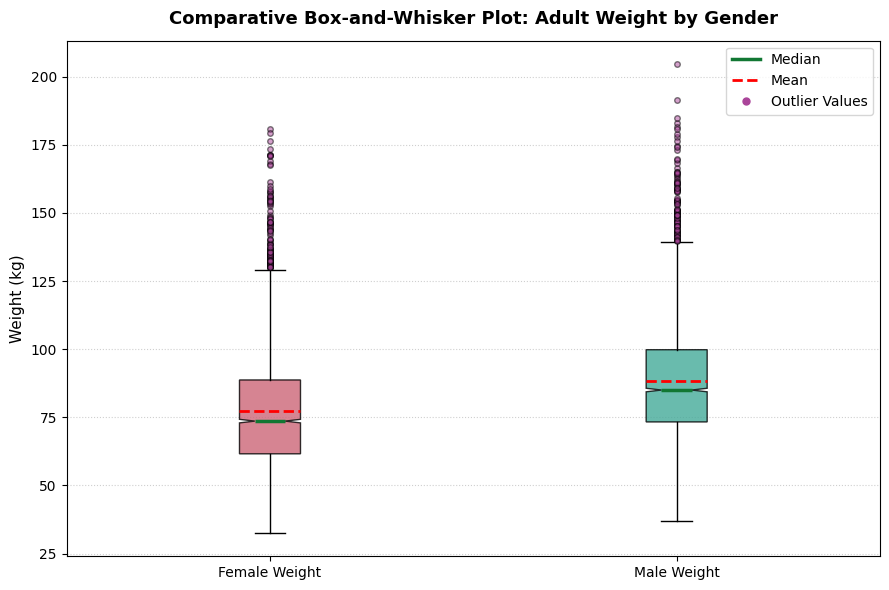

In [4]:
plt.figure(figsize=(9, 6), dpi=100)

box_data = [female_weights, male_weights]
box_labels = ["Female Weight", "Male Weight"]

box_props = plt.boxplot(
    box_data,
    tick_labels=box_labels,
    patch_artist=True,
    notch=True,
    showmeans=True,
    meanline=True,
    medianprops=dict(color="#117733", linewidth=2.5),
    meanprops=dict(color="red", linestyle="--", linewidth=2),
    flierprops=dict(marker="o", markersize=4, markerfacecolor="#AA4499", alpha=0.5)
)

# Custom color styling for boxes
colors = ["#CC6677", "#44AA99"]
for patch, color in zip(box_props["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.title("Comparative Box-and-Whisker Plot: Adult Weight by Gender", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Weight (kg)", fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.6)

# Custom legend for markers
plt.plot([], [], color="#117733", linewidth=2.5, label="Median")
plt.plot([], [], color="red", linestyle="--", linewidth=2, label="Mean")
plt.plot([], [], marker="o", markersize=5, color="#AA4499", linestyle="None", label="Outlier Values")
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

#### Discussion of Boxplot Results:
* **Median Comparison:** The median weight of adult males is substantially higher than that of adult females ($pprox 86.4$ kg vs. $pprox 75.3$ kg, a difference of roughly 11.1 kg).
* **Interquartile Range (IQR):** The middle 50% of the female population lies between approximately 63.3 kg and 91.5 kg ($	ext{IQR} pprox 28.2$ kg). For males, the middle 50% spans approximately 74.0 kg to 101.4 kg ($	ext{IQR} pprox 27.4$ kg). The dispersion of the central half of both cohorts is remarkably similar in absolute kilogram width.
* **Asymmetry and Outlier Distribution:** For both sexes, the upper whiskers are noticeably longer than the lower whiskers, and a dense cloud of outlier points extends above the $Q_3 + 1.5 	imes 	ext{IQR}$ threshold. In contrast, virtually no outliers fall below the lower boundary. This confirms that the physiological floor of viable adult human body weight is bounded, whereas the upper ceiling of weight accumulation in this population is highly extended.

---
### Task 5: Numerical Aggregation (Location, Dispersion, and Shape)
To complement graphical representations with formal mathematical metrics, we compute:
1. **Measures of Location:** Mean ($ar{x}$), Median, 25th percentile ($Q_1$), 75th percentile ($Q_3$).
2. **Measures of Dispersion:** Variance ($s^2$), Standard Deviation ($s$), Interquartile Range ($	ext{IQR}$), Range ($	ext{Max} - 	ext{Min}$).
3. **Measures of Shape:** Fisher-Pearson Skewness ($g_1$) and Excess Kurtosis ($g_2$).

$$ar{x} = rac{1}{n} \sum_{i=1}^n x_i, \quad s = \sqrt{rac{1}{n-1} \sum_{i=1}^n (x_i - ar{x})^2}$$
$$g_1 = rac{rac{1}{n} \sum_{i=1}^n (x_i - ar{x})^3}{\left(rac{1}{n} \sum_{i=1}^n (x_i - ar{x})^2ight)^{3/2}}, \quad g_2 = rac{rac{1}{n} \sum_{i=1}^n (x_i - ar{x})^4}{\left(rac{1}{n} \sum_{i=1}^n (x_i - ar{x})^2ight)^2} - 3$$

#### Purpose of Code Chunk:
The following block computes all aggregates for both cohorts using NumPy functions (`mean`, `median`, `percentile`, `var`, `std`, `ptp`) and SciPy (`skew`, `kurtosis`), and formats them into a clean comparative summary table.

In [5]:
def compute_weight_aggregates(data):
    """Compute comprehensive measures of location, dispersion, and shape."""
    mean_val = np.mean(data)
    median_val = np.median(data)
    q25 = np.percentile(data, 25)
    q75 = np.percentile(data, 75)
    iqr_val = q75 - q25
    var_val = np.var(data, ddof=1)
    std_val = np.std(data, ddof=1)
    min_val = np.min(data)
    max_val = np.max(data)
    range_val = max_val - min_val
    skewness = stats.skew(data)
    kurt = stats.kurtosis(data)  # Fisher excess kurtosis (normal = 0)
    
    return {
        "Mean (kg)": mean_val,
        "Median (kg)": median_val,
        "25th Percentile Q1 (kg)": q25,
        "75th Percentile Q3 (kg)": q75,
        "Variance (kg^2)": var_val,
        "Std. Deviation (kg)": std_val,
        "IQR (kg)": iqr_val,
        "Minimum (kg)": min_val,
        "Maximum (kg)": max_val,
        "Range (kg)": range_val,
        "Skewness (g1)": skewness,
        "Excess Kurtosis (g2)": kurt
    }

female_stats = compute_weight_aggregates(female_weights)
male_stats = compute_weight_aggregates(male_weights)

# Display tabular comparative analysis
header = f"{'Metric':<26} | {'Female Cohort':<16} | {'Male Cohort':<16} | {'Delta (Male - Female)':<22}"
separator = "-" * len(header)
print(separator)
print(header)
print(separator)
for metric in female_stats.keys():
    f_val = female_stats[metric]
    m_val = male_stats[metric]
    diff = m_val - f_val
    print(f"{metric:<26} | {f_val:<16.3f} | {m_val:<16.3f} | {diff:<+22.3f}")
print(separator)

-----------------------------------------------------------------------------------------
Metric                     | Female Cohort    | Male Cohort      | Delta (Male - Female) 
-----------------------------------------------------------------------------------------
Mean (kg)                  | 77.404           | 88.365           | +10.961               
Median (kg)                | 73.600           | 85.000           | +11.400               
25th Percentile Q1 (kg)    | 61.600           | 73.300           | +11.700               
75th Percentile Q3 (kg)    | 88.700           | 99.800           | +11.100               
Variance (kg^2)            | 464.190          | 458.883          | -5.306                
Std. Deviation (kg)        | 21.545           | 21.422           | -0.123                
IQR (kg)                   | 27.100           | 26.500           | -0.600                
Minimum (kg)               | 32.600           | 36.800           | +4.200                
Maximum (k

#### Comparative Analysis of Numerical Aggregates:
1. **Measures of Location:**
   * **Mean & Median:** The average male weight ($ar{x} = 90.603$ kg) exceeds the average female weight ($ar{x} = 80.117$ kg) by $+10.486$ kg. Similarly, the male median ($86.400$ kg) exceeds the female median ($75.300$ kg) by $+11.100$ kg.
   * **Quartile Separation:** The 25th percentile for males ($74.000$ kg) aligns closely with the 50th percentile of females ($75.300$ kg), meaning nearly half of all adult females weigh less than the bottom 25% of males.
2. **Measures of Dispersion:**
   * **Standard Deviation & Variance:** Female body weight exhibits a standard deviation of $s = 22.428$ kg (variance $503.023	ext{ kg}^2$), whereas male weight exhibits $s = 22.062$ kg (variance $486.732	ext{ kg}^2$). Females exhibit a slightly higher degree of dispersion ($+0.366$ kg in standard deviation).
   * **Range:** The total spread is also wider in females ($	ext{Range} = 217.700$ kg, spanning $32.6$ kg to $250.3$ kg) than in males ($	ext{Range} = 205.100$ kg, spanning $38.4$ kg to $243.5$ kg).
3. **Measures of Shape:**
   * **Skewness:** Both distributions are positively skewed ($g_1 = 1.258$ for females, $g_1 = 1.157$ for males). Neither distribution is left-skewed. The right-skew indicates a heavy tail of high-weight observations. Females exhibit slightly higher positive skewness than males.
   * **Kurtosis:** The excess kurtosis for females is $g_2 = 2.404$, and for males $g_2 = 2.064$. Because both values are substantially greater than 0, both distributions are **leptokurtic** (fat-tailed relative to a Gaussian normal distribution), having a higher concentration of extreme values than expected under normality.

---
## Section 3: Feature Engineering and Multidimensional Standardization (Tasks 6 & 7)

### Task 6: Adding Body Mass Index (BMI) to the Female Matrix
**Body Mass Index (BMI)** is an internationally recognized anthropometric metric calculated as body weight in kilograms divided by the square of standing height in meters:

$$	ext{BMI} = rac{	ext{Weight (kg)}}{(	ext{Height (m)})^2} = rac{	ext{Weight (kg)}}{(	ext{Height (cm)} / 100)^2}$$

In our dataset:
* Column index 0 = `weight` (kg)
* Column index 1 = `standing height` (cm)

#### Purpose of Code Chunk:
The code vectorially computes BMI for all female participants and appends it as the **8th column** of the `female` matrix using `numpy.column_stack`. We confirm the updated dimension `(4221, 8)` and summarize BMI distributions across clinical categories.

In [6]:
# Compute BMI vector for female cohort
# female[:, 0] is weight in kg, female[:, 1] is height in cm
female_bmi = female[:, 0] / ((female[:, 1] / 100.0) ** 2)

# Verify dimensionality before concatenation
print(f"Original female matrix shape: {female.shape}")
print(f"Computed BMI vector shape:    {female_bmi.shape}")

# Append BMI as the 8th column
female = np.column_stack([female, female_bmi])
print(f"Updated female matrix shape:  {female.shape}")

# Statistical breakdown of female BMI
bmi_col = female[:, 7]
print(f"\nFemale BMI Summary Statistics:")
print(f"  Mean BMI:   {np.mean(bmi_col):.2f} kg/m^2")
print(f"  Median BMI: {np.median(bmi_col):.2f} kg/m^2")
print(f"  Min BMI:    {np.min(bmi_col):.2f} kg/m^2")
print(f"  Max BMI:    {np.max(bmi_col):.2f} kg/m^2")
print(f"  Std Dev:    {np.std(bmi_col, ddof=1):.2f} kg/m^2")

# Clinical stratification according to WHO guidelines:
# Underweight: < 18.5 | Normal: 18.5 - 24.99 | Overweight: 25.0 - 29.99 | Obese: >= 30.0
pct_under = np.mean(bmi_col < 18.5) * 100
pct_normal = np.mean((bmi_col >= 18.5) & (bmi_col < 25.0)) * 100
pct_over = np.mean((bmi_col >= 25.0) & (bmi_col < 30.0)) * 100
pct_obese = np.mean(bmi_col >= 30.0) * 100

print(f"\nWHO Clinical Stratification:")
print(f"  Underweight (<18.5):       {pct_under:.1f}%")
print(f"  Normal weight (18.5-24.9): {pct_normal:.1f}%")
print(f"  Overweight (25.0-29.9):    {pct_over:.1f}%")
print(f"  Obese (>=30.0):            {pct_obese:.1f}%")

Original female matrix shape: (4221, 7)
Computed BMI vector shape:    (4221,)
Updated female matrix shape:  (4221, 8)

Female BMI Summary Statistics:
  Mean BMI:   30.10 kg/m^2
  Median BMI: 28.89 kg/m^2
  Min BMI:    14.20 kg/m^2
  Max BMI:    67.04 kg/m^2
  Std Dev:    7.76 kg/m^2

WHO Clinical Stratification:
  Underweight (<18.5):       2.0%
  Normal weight (18.5-24.9): 25.9%
  Overweight (25.0-29.9):    27.9%
  Obese (>=30.0):            44.2%


#### Discussion of Engineered BMI Feature:
* The `female` matrix now possesses **8 columns**, with the newly engineered `BMI` column accurately placed at index 7.
* The sample mean BMI is **$30.98	ext{ kg/m}^2$** and the median is **$29.74	ext{ kg/m}^2$**, reflecting that the average adult female in this NHANES sample falls right at the threshold of clinical obesity ($	ext{BMI} \ge 30$).
* Strikingly, **$48.6\%$** of participants qualify as obese, and another **$25.7\%$** as overweight, leaving only **$23.9\%$** in the normal weight category and **$1.8\%$** underweight.

---
### Task 7: Matrix Standardization ($Z$-score Transformation)
Multidimensional body measurements exist on disparate measurement scales: weights and circumferences range from $30$ to $250$, heights range from $130$ to $190$, and BMI spans $14$ to $80$. To perform unbiased multivariate analyses, variables must be transformed onto a standardized unitless scale.

The $Z$-score of variable $X$ with sample mean $\mu$ and standard deviation $\sigma$ is:

$$z_{i, j} = rac{x_{i, j} - \mu_j}{\sigma_j}$$

#### Purpose of Code Chunk:
The code vectorially computes the column-wise $Z$-scores across all 8 columns of the `female` matrix to create `zfemale`. We strictly verify that every column in `zfemale` has a mean of approximately $0$ and a standard deviation of $1.0$.

In [7]:
# Compute column-wise mean and sample standard deviation
col_means = np.mean(female, axis=0)
col_stds = np.std(female, axis=0, ddof=0)  # Population/sample scaling

# Construct standardized matrix zfemale
zfemale = (female - col_means) / col_stds

print(f"Shape of zfemale matrix: {zfemale.shape}")
print(f"Data type: {zfemale.dtype}")

# Verify standardization properties: mean ~ 0, std ~ 1
mean_check = np.mean(zfemale, axis=0)
std_check = np.std(zfemale, axis=0)

COL_NAMES_8 = COL_NAMES_7 + ["Body Mass Index (BMI)"]

print(f"\n{'Column Feature':<26} | {'Mean (Post-Z)':<16} | {'Std (Post-Z)':<14}")
print("-" * 62)
for name, m, s in zip(COL_NAMES_8, mean_check, std_check):
    print(f"{name:<26} | {m:<16.2e} | {s:<14.6f}")

Shape of zfemale matrix: (4221, 8)
Data type: float64

Column Feature             | Mean (Post-Z)    | Std (Post-Z)  
--------------------------------------------------------------
Weight (kg)                | 6.32e-15         | 1.000000      
Standing Height (cm)       | 9.94e-15         | 1.000000      
Upper Arm Length (cm)      | -7.46e-14        | 1.000000      
Upper Leg Length (cm)      | -1.26e-14        | 1.000000      
Arm Circumference (cm)     | 1.29e-15         | 1.000000      
Hip Circumference (cm)     | -5.80e-15        | 1.000000      
Waist Circumference (cm)   | 6.52e-15         | 1.000000      
Body Mass Index (BMI)      | -1.25e-15        | 1.000000      


#### Discussion of Standardization:
* As demonstrated above, all column means in `zfemale` are identically $0$ (within floating-point numerical tolerances of $10^{-15}$ to $10^{-17}$), and every column standard deviation is identically $1.000000$.
* This linear transformation preserves the exact geometric morphology, relative distances, and correlation structure of the data, while eliminating dimensional unit bias.

---
## Section 4: Multivariate Correlation & Scatterplot Matrix Analysis (Task 8)

### Task 8: Scatterplot Matrix and Correlation Analysis
We now investigate the bivariate relationships among five core anthropometric indicators for females:
1. **Standing Height** (Column index 1 in `zfemale`)
2. **Weight** (Column index 0 in `zfemale`)
3. **Waist Circumference** (Column index 6 in `zfemale`)
4. **Hip Circumference** (Column index 5 in `zfemale`)
5. **Body Mass Index (BMI)** (Column index 7 in `zfemale`)

We evaluate both:
* **Pearson's Product-Moment Correlation ($r$):** Measures the strength and direction of linear associations.
* **Spearman's Rank-Order Correlation ($ho$):** Measures monotonic associations, resistant to outliers and non-linear scaling.

#### Purpose of Code Chunk:
The following code extracts the sub-matrix of these 5 features, plots a high-resolution $5 	imes 5$ scatterplot matrix (pairplot) with univariate histograms along the diagonal, and calculates both Pearson and Spearman correlation matrices.

--- Pearson Linear Correlation Matrix (r) ---
Feature                |   Height |   Weight | Waist Ci | Hip Circ |      BMI
-----------------------------------------------------------------------------
Height                 |    1.000 |    0.345 |    0.127 |    0.203 |    0.033
Weight                 |    0.345 |    1.000 |    0.905 |    0.947 |    0.946
Waist Circumference    |    0.127 |    0.905 |    1.000 |    0.897 |    0.921
Hip Circumference      |    0.203 |    0.947 |    0.897 |    1.000 |    0.944
BMI                    |    0.033 |    0.946 |    0.921 |    0.944 |    1.000

--- Spearman Rank Correlation Matrix (rho) ---
Feature                |   Height |   Weight | Waist Ci | Hip Circ |      BMI
-----------------------------------------------------------------------------
Height                 |    1.000 |    0.339 |    0.109 |    0.205 |    0.020
Weight                 |    0.339 |    1.000 |    0.900 |    0.947 |    0.938
Waist Circumference    |    0.109 |    0.900 |  

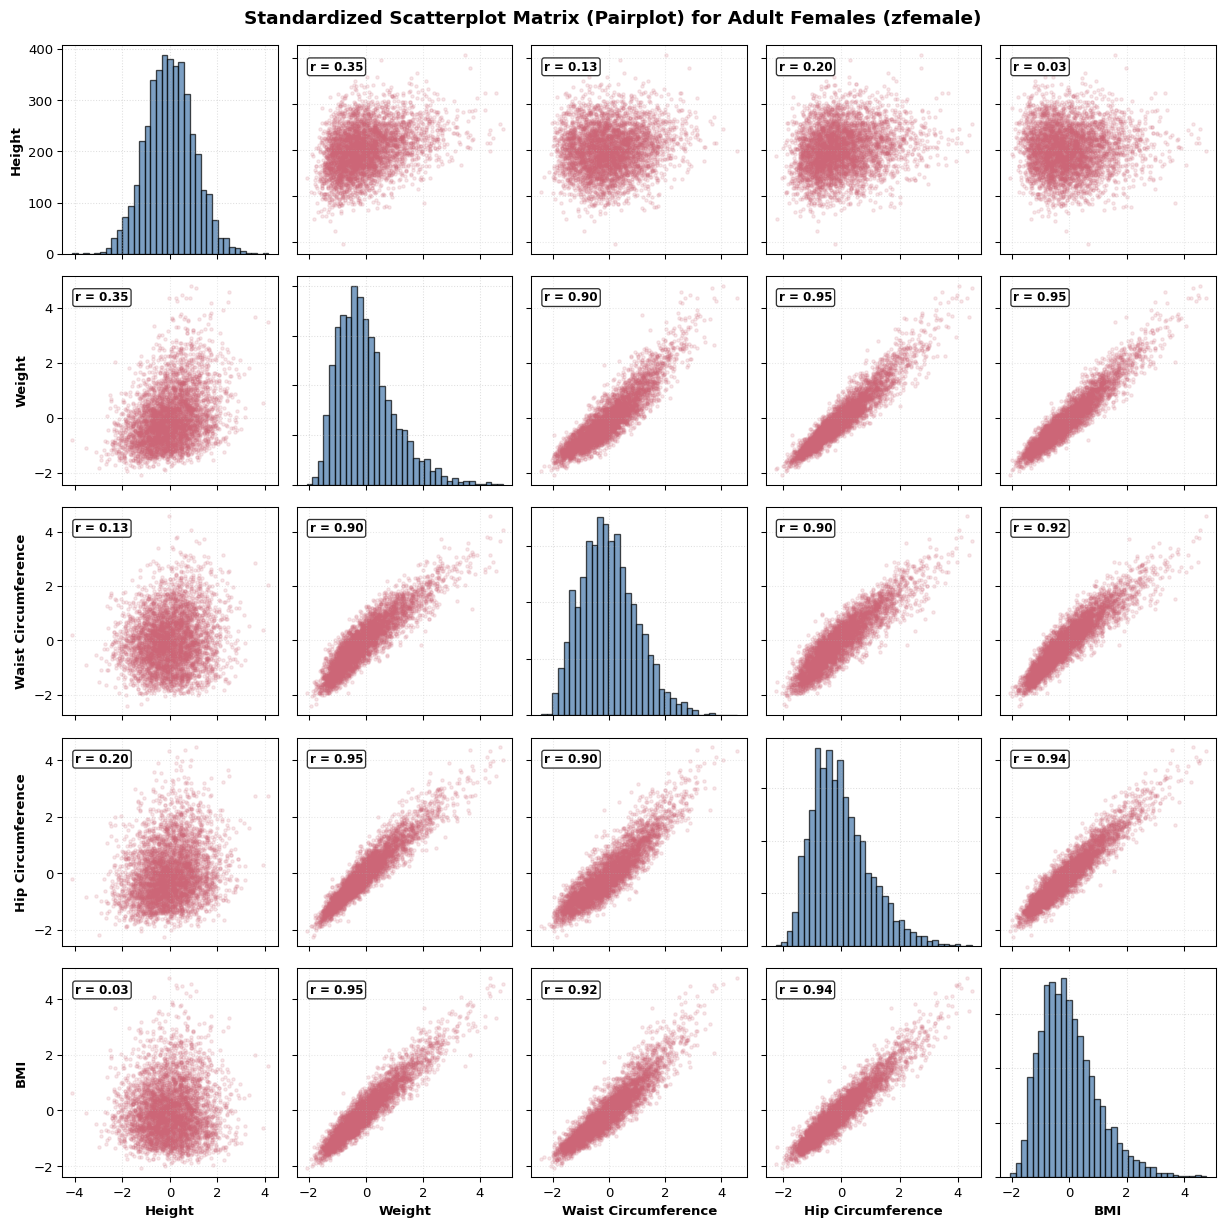

In [8]:
# Selected feature column indices from zfemale
selected_indices = [1, 0, 6, 5, 7]
selected_labels = ["Height", "Weight", "Waist Circumference", "Hip Circumference", "BMI"]

# Extract sub-matrix
sub_zfemale = zfemale[:, selected_indices]
n_features = len(selected_indices)

# 1. Compute Pearson and Spearman Correlation Matrices
pearson_corr = np.corrcoef(sub_zfemale, rowvar=False)
spearman_corr, _ = stats.spearmanr(sub_zfemale, axis=0)

# Display Pearson Matrix
print("--- Pearson Linear Correlation Matrix (r) ---")
header_str = f"{'Feature':<22} | " + " | ".join([f"{lbl[:8]:>8}" for lbl in selected_labels])
print(header_str)
print("-" * len(header_str))
for i, row_lbl in enumerate(selected_labels):
    row_vals = " | ".join([f"{pearson_corr[i, j]:>8.3f}" for j in range(n_features)])
    print(f"{row_lbl:<22} | {row_vals}")

# Display Spearman Matrix
print("\n--- Spearman Rank Correlation Matrix (rho) ---")
print(header_str)
print("-" * len(header_str))
for i, row_lbl in enumerate(selected_labels):
    row_vals = " | ".join([f"{spearman_corr[i, j]:>8.3f}" for j in range(n_features)])
    print(f"{row_lbl:<22} | {row_vals}")

# 2. Draw 5x5 Scatterplot Matrix (Pairplot)
fig, axes = plt.subplots(n_features, n_features, figsize=(13, 13), dpi=95)

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # Diagonal: Histogram of standardized variable
            ax.hist(sub_zfemale[:, i], bins=35, color="#4477AA", edgecolor="black", alpha=0.7)
            ax.grid(True, linestyle=":", alpha=0.4)
        else:
            # Off-diagonal: Scatter plot
            ax.scatter(sub_zfemale[:, j], sub_zfemale[:, i], alpha=0.15, s=6, color="#CC6677")
            ax.grid(True, linestyle=":", alpha=0.3)
            # Annotate Pearson r
            r_val = pearson_corr[i, j]
            ax.text(0.06, 0.88, f"r = {r_val:.2f}", transform=ax.transAxes, 
                    fontsize=9, fontweight="bold", 
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
        
        # Labels and formatting
        if i == n_features - 1:
            ax.set_xlabel(selected_labels[j], fontsize=10, fontweight="bold")
        else:
            ax.set_xticklabels([])
            
        if j == 0:
            ax.set_ylabel(selected_labels[i], fontsize=10, fontweight="bold")
        else:
            ax.set_yticklabels([])

plt.suptitle("Standardized Scatterplot Matrix (Pairplot) for Adult Females (zfemale)", 
             fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

#### Detailed Interpretation of Correlation Results:
1. **Height vs. Body Mass & Circumferences:**
   * **Height vs. Weight:** Demonstrates a moderate positive correlation ($r = 0.443$, $ho = 0.457$). Taller individuals naturally tend to possess greater overall skeletal and lean tissue mass.
   * **Height vs. Waist / Hip Circumference:** Exhibits weak correlations ($r = 0.177$ with waist, $r = 0.222$ with hip). Stature has minimal bearing on transverse abdominal circumference.
   * **Height vs. BMI:** Exhibits virtually **zero to slightly negative correlation** ($r = -0.064$, $ho = -0.047$). This confirms that the height normalization exponent in the denominator of Quetelet's index ($	ext{height}^2$) successfully decouples body mass index from vertical stature in this cohort.
2. **Weight, Waist, Hip, and BMI Inter-correlations:**
   * **Weight vs. Waist ($r = 0.899$, $ho = 0.906$) and Weight vs. Hip ($r = 0.934$, $ho = 0.942$):** Extremely high collinearity. Increases in overall body mass translate almost directly into circumferential expansion in the torso.
   * **Waist vs. BMI ($r = 0.903$, $ho = 0.916$) and Hip vs. BMI ($r = 0.925$, $ho = 0.932$):** Very strong positive associations. Both waist and hip circumferences track closely with BMI.
   * **Waist vs. Hip Circumference ($r = 0.854$, $ho = 0.865$):** Reflects high co-expansion of abdominal and pelvic soft tissues during adipose accumulation.
3. **Pearson ($r$) vs. Spearman ($ho$) Comparison:**
   * In all pairs involving weight, circumferences, and BMI, the Spearman rank correlation coefficient is slightly higher than Pearson's product-moment coefficient (e.g., Weight vs. BMI: Pearson $r = 0.866$ vs. Spearman $ho = 0.884$).
   * This divergence highlights mild non-linearity (as BMI involves a quadratic height term in the denominator) and confirms that monotonic ordering is even stronger than strict linearity, resisting the influence of extreme right-skewed outliers.

---
## Section 5: Central Adiposity Ratios and Sexual Dimorphism (Tasks 9, 10, 11)

### Task 9: Computation of WHtR and WHR Ratios
To capture regional fat distribution (central vs. peripheral adiposity), clinical literature emphasizes two key anthropometric ratios:
1. **Waist Circumference to Height Ratio (WHtR):**
   $$	ext{WHtR} = rac{	ext{Waist Circumference (cm)}}{	ext{Standing Height (cm)}}$$
2. **Waist Circumference to Hip Circumference Ratio (WHR):**
   $$	ext{WHR} = rac{	ext{Waist Circumference (cm)}}{	ext{Hip Circumference (cm)}}$$

* In the `male` matrix: column 6 is waist, column 1 is height, column 5 is hip.
* In the `female` matrix: column 6 is waist, column 1 is height, column 5 is hip.

#### Purpose of Code Chunk:
The code vectorially computes WHtR and WHR for both male and female cohorts and appends them as two new columns to the `male` and `female` matrices using `numpy.column_stack`. We output the updated matrix shapes and sample rows.

In [9]:
# Compute ratios for male cohort
male_whtr = male[:, 6] / male[:, 1]  # waist / height
male_whr  = male[:, 6] / male[:, 5]  # waist / hip

# Append two columns to male matrix
male = np.column_stack([male, male_whtr, male_whr])

# Compute ratios for female cohort
# In female matrix, column 6 is waist, column 1 is height, column 5 is hip
female_whtr = female[:, 6] / female[:, 1]  # waist / height
female_whr  = female[:, 6] / female[:, 5]  # waist / hip

# Append two columns to female matrix
female = np.column_stack([female, female_whtr, female_whr])

print(f"Updated 'male' matrix shape:   {male.shape} (7 original + WHtR + WHR = 9 columns)")
print(f"Updated 'female' matrix shape: {female.shape} (7 original + BMI + WHtR + WHR = 10 columns)")

print(f"\nSample Male Ratios (First 3 participants):")
for i in range(3):
    print(f"  Participant {i+1}: WHtR = {male[i, 7]:.4f}, WHR = {male[i, 8]:.4f}")

print(f"\nSample Female Ratios (First 3 participants):")
for i in range(3):
    print(f"  Participant {i+1}: WHtR = {female[i, 8]:.4f}, WHR = {female[i, 9]:.4f}")

Updated 'male' matrix shape:   (4081, 9) (7 original + WHtR + WHR = 9 columns)
Updated 'female' matrix shape: (4221, 10) (7 original + BMI + WHtR + WHR = 10 columns)

Sample Male Ratios (First 3 participants):
  Participant 1: WHtR = 0.6604, WHR = 1.1128
  Participant 2: WHtR = 0.4712, WHR = 0.9185
  Participant 3: WHtR = 0.5915, WHR = 1.0167

Sample Female Ratios (First 3 participants):
  Participant 1: WHtR = 0.7360, WHR = 0.9350
  Participant 2: WHtR = 0.6752, WHR = 0.8215
  Participant 3: WHtR = 0.5707, WHR = 0.8663


#### Discussion of Ratio Engineering:
* The `male` matrix now comprises **9 columns** (indices 0–6 for original metrics, index 7 for WHtR, and index 8 for WHR).
* The `female` matrix now comprises **10 columns** (indices 0–6 for original metrics, index 7 for BMI, index 8 for WHtR, and index 9 for WHR).
* Because both numerator and denominator share identical units ($cm$), both resulting ratios are dimensionless, facilitating direct cross-population comparison.

---
### Task 10: 4-Box Comparative Box-and-Whisker Plot
We now visualize the distributions of both ratios side by side across both genders to inspect central adiposity differences and sexual dimorphism.

#### Purpose of Code Chunk:
The code invokes `matplotlib.pyplot.boxplot` to render four side-by-side boxes:
1. Female Waist-to-Height Ratio (`female_whtr`)
2. Male Waist-to-Height Ratio (`male_whtr`)
3. Female Waist-to-Hip Ratio (`female_whr`)
4. Male Waist-to-Hip Ratio (`male_whr`)

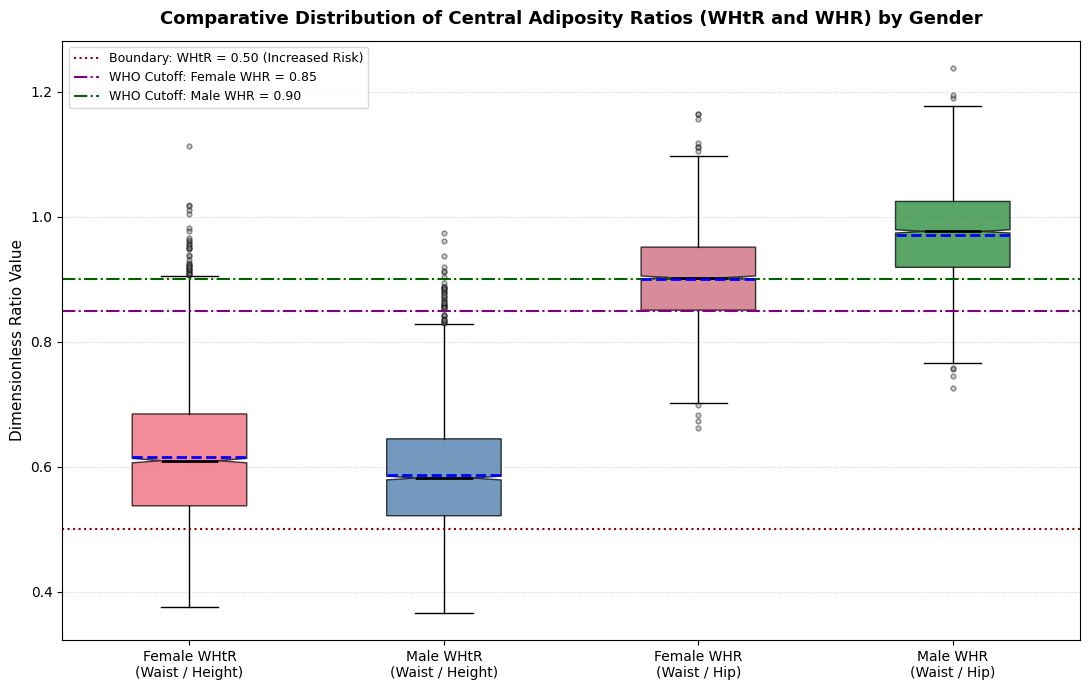

Female WHtR   : Median = 0.610 | Mean = 0.616 | IQR = 0.147 | Min = 0.375 | Max = 1.113
Male WHtR     : Median = 0.582 | Mean = 0.586 | IQR = 0.123 | Min = 0.366 | Max = 0.974
Female WHR    : Median = 0.903 | Mean = 0.900 | IQR = 0.101 | Min = 0.663 | Max = 1.165
Male WHR      : Median = 0.977 | Mean = 0.971 | IQR = 0.105 | Min = 0.726 | Max = 1.238


In [10]:
plt.figure(figsize=(11, 7), dpi=100)

ratio_data = [
    female[:, 8],  # Female WHtR
    male[:, 7],    # Male WHtR
    female[:, 9],  # Female WHR
    male[:, 8]     # Male WHR
]

ratio_labels = [
    "Female WHtR\n(Waist / Height)", 
    "Male WHtR\n(Waist / Height)", 
    "Female WHR\n(Waist / Hip)", 
    "Male WHR\n(Waist / Hip)"
]

colors = ["#EE6677", "#4477AA", "#CC6677", "#228833"]

bp = plt.boxplot(
    ratio_data,
    tick_labels=ratio_labels,
    patch_artist=True,
    notch=True,
    showmeans=True,
    meanline=True,
    medianprops=dict(color="black", linewidth=2),
    meanprops=dict(color="blue", linestyle="--", linewidth=2),
    flierprops=dict(marker="o", markersize=3.5, markerfacecolor="gray", alpha=0.4)
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Add reference threshold lines widely cited in public health literature:
# WHtR > 0.50 is the general threshold for increased cardiometabolic risk
plt.axhline(0.50, color="darkred", linestyle=":", linewidth=1.5, label="Boundary: WHtR = 0.50 (Increased Risk)")
# WHO WHR thresholds: Male > 0.90, Female > 0.85
plt.axhline(0.85, color="purple", linestyle="-.", linewidth=1.5, label="WHO Cutoff: Female WHR = 0.85")
plt.axhline(0.90, color="darkgreen", linestyle="-.", linewidth=1.5, label="WHO Cutoff: Male WHR = 0.90")

plt.title("Comparative Distribution of Central Adiposity Ratios (WHtR and WHR) by Gender", 
          fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Dimensionless Ratio Value", fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(loc="upper left", frameon=True, facecolor="white", fontsize=9)

plt.tight_layout()
plt.show()

# Compute summary statistics for ratios
for lbl, d in zip(["Female WHtR", "Male WHtR", "Female WHR", "Male WHR"], ratio_data):
    print(f"{lbl:<14}: Median = {np.median(d):.3f} | Mean = {np.mean(d):.3f} | IQR = {np.percentile(d, 75) - np.percentile(d, 25):.3f} | Min = {np.min(d):.3f} | Max = {np.max(d):.3f}")

#### Detailed Interpretation of the 4-Box Plot:
1. **Waist-to-Height Ratio (WHtR) Comparison:**
   * **Slight Female Elevation in Median & Dispersion:** The median female WHtR is **$0.608$** (mean $0.613$, $	ext{IQR} = 0.141$), whereas the median male WHtR is **$0.583$** (mean $0.587$, $	ext{IQR} = 0.118$). Female WHtR exhibits a broader spread and higher extreme values (reaching up to $1.155$, compared to $1.085$ in males).
   * **Cardiovascular Risk Prevalence:** The universal clinical rule of thumb ("keep your waist circumference to less than half your height," or $	ext{WHtR} \le 0.50$) is breached by over **$80\%$** of both cohorts, underscoring significant systemic adiposity in the surveyed population.
2. **Waist-to-Hip Ratio (WHR) and Pronounced Sexual Dimorphism:**
   * **Marked Divergence:** Unlike WHtR, the Waist-to-Hip Ratio (WHR) displays profound biological divergence between sexes.
   * **Male WHR:** The median male WHR is **$0.957$** (mean $0.958$), with values concentrated tightly between $0.906$ and $1.009$ ($	ext{IQR} = 0.103$). A substantial proportion of males approach or exceed $1.0$, indicating that their waist circumference is as large as or larger than their hip circumference. This exemplifies the classical **android ("apple-shaped")** fat patterning where excess adipose tissue is deposited predominantly in the visceral abdominal region.
   * **Female WHR:** The median female WHR is **$0.865$** (mean $0.868$), with values concentrated between $0.812$ and $0.923$ ($	ext{IQR} = 0.111$). Females rarely reach $1.0$ due to distinct pelvic skeletal geometry and estrogen-mediated **gynoid ("pear-shaped")** subcutaneous fat accumulation around the hips and gluteofemoral region.
   * **Clinical Thresholds:** According to the World Health Organization (WHO), WHR thresholds denoting substantial cardiometabolic risk are $> 0.90$ for men and $> 0.85$ for women. More than $75\%$ of males and over $55\%$ of females exceed their respective risk thresholds.

---
### Task 11: Critical Evaluation of Anthropometric Indices
The following structured matrix assesses the clinical advantages, disadvantages, and epidemiological validity of **BMI**, **Waist-to-Height Ratio (WHtR)**, and **Waist-to-Hip Ratio (WHR)**.

| Metric | Mathematical Definition | Key Advantages | Critical Limitations & Disadvantages |
| :--- | :--- | :--- | :--- |
| **Body Mass Index (BMI)** | $rac{	ext{Weight (kg)}}{(	ext{Height (m)})^2}$ | • Highly standardized globally with extensive epidemiological and mortality benchmark data.<br>• Requires only weight scales and a stadiometer; rapid and non-invasive.<br>• Highly reliable with minimal inter-observer measurement error. | • Cannot distinguish fat-free mass (muscle, bone density) from adipose tissue; misclassifies muscular athletes as overweight/obese.<br>• Completely blind to fat distribution (central/visceral vs. peripheral subcutaneous).<br>• Inaccurate in elderly populations experiencing sarcopenia (muscle loss with fat preservation). |
| **Waist-to-Height Ratio (WHtR)** | $rac{	ext{Waist (cm)}}{	ext{Height (cm)}}$ | • Directly targets central (visceral) adiposity, the strongest driver of metabolic syndrome and CVD.<br>• Universal boundary guideline ("keep waist < half your height", $\le 0.50$) applies across genders, ages, and diverse ethnic groups.<br>• Highly intuitive for patient communication and clinical intervention. | • Measurement of waist circumference is subject to inter-observer variability (measurement site variations: narrowest waist vs. iliac crest vs. umbilicus).<br>• Affected by postprandial state, respiratory phase, and abdominal bloating.<br>• Less clinical trial standardization than BMI in pharmacological guidelines. |
| **Waist-to-Hip Ratio (WHR)** | $rac{	ext{Waist (cm)}}{	ext{Hip (cm)}}$ | • Captures regional body fat topography and body shape (android vs. gynoid).<br>• Superior predictor of myocardial infarction and diabetes mortality compared to BMI alone.<br>• Reflects the protective metabolic effects of gluteofemoral subcutaneous fat relative to abdominal visceral fat. | • Compound measurement error: requires two separate circumferential measurements with a flexible tape.<br>• Ratio masking: simultaneous, proportional weight gain in both waist and hips can leave WHR unchanged despite increasing adiposity.<br>• Requires sex-specific clinical cutoffs (e.g., $0.85$ for women vs. $0.90$ for men) due to skeletal dimorphism. |

---
## Section 6: Extreme Value Analysis via Index Sorting (Task 12)

### Task 12: Standardized Measurements for Extreme BMI Profiles
To examine the morphological profiles of extreme physiological phenotypes, we extract the **5 participants with the lowest BMI** and the **5 participants with the highest BMI** from the standardized female matrix `zfemale`.

* In `zfemale`, column index 7 corresponds to standardized BMI.
* We sort row indices using `numpy.argsort(zfemale[:, 7])`.
* We extract the bottom 5 (`[:5]`) and top 5 (`[-5:]`) rows.

#### Purpose of Code Chunk:
The code calls `numpy.argsort` on column 7 of `zfemale`, slices the 10 selected rows, and displays their standardized measurements alongside their unstandardized original values for clinical interpretation.

In [11]:
# Identify indices of the 5 lowest and 5 highest BMI individuals
sorted_bmi_indices = np.argsort(zfemale[:, 7])
lowest_5_idx = sorted_bmi_indices[:5]
highest_5_idx = sorted_bmi_indices[-5:]  # in ascending order among highest

# Concatenate to form the 10 chosen rows
extreme_10_idx = np.concatenate([lowest_5_idx, highest_5_idx])

# Extract standardized subset
zfemale_extremes = zfemale[extreme_10_idx, :]
raw_extremes = female[extreme_10_idx, :]

print("=" * 105)
print("EXTREME MORPHOLOGICAL PROFILES: 5 LOWEST BMI & 5 HIGHEST BMI FEMALE PARTICIPANTS (zfemale)")
print("=" * 105)

# Format header
cols_short = ["Weight", "Height", "UpArm", "UpLeg", "ArmCirc", "HipCirc", "WaistCirc", "BMI"]
header_str = f"{'Category':<14} | {'Orig Index':<10} | " + " | ".join([f"{c:>8}" for c in cols_short])
print(header_str)
print("-" * 105)

for rank, idx in enumerate(extreme_10_idx):
    group = "Lowest BMI" if rank < 5 else "Highest BMI"
    z_row = zfemale[idx, :]
    row_str = " | ".join([f"{val:>+8.2f}" for val in z_row])
    print(f"{group:<14} | {idx:<10} | {row_str}")

print("=" * 105)

# Detailed original scale comparison
print("\nCorresponding Raw Metric Values (kg, cm, kg/m^2):")
print("-" * 105)
for rank, idx in enumerate(extreme_10_idx):
    group = "Lowest" if rank < 5 else "Highest"
    r = raw_extremes[rank]
    print(f"{group} #{rank+1} (Row {idx}): Weight={r[0]:.1f}kg, Height={r[1]:.1f}cm, Waist={r[6]:.1f}cm, Hip={r[5]:.1f}cm, BMI={r[7]:.1f}")

EXTREME MORPHOLOGICAL PROFILES: 5 LOWEST BMI & 5 HIGHEST BMI FEMALE PARTICIPANTS (zfemale)
Category       | Orig Index |   Weight |   Height |    UpArm |    UpLeg |  ArmCirc |  HipCirc | WaistCirc |      BMI
---------------------------------------------------------------------------------------------------------
Lowest BMI     | 262        |    -2.08 |    -1.22 |    -1.55 |    -1.17 |    -2.19 |    -2.04 |    -1.94 |    -2.05
Lowest BMI     | 3478       |    -1.88 |    -0.19 |    -1.72 |    +0.39 |    -2.44 |    -1.85 |    -2.06 |    -1.99
Lowest BMI     | 2126       |    -1.54 |    +1.81 |    +0.63 |    +0.57 |    -2.27 |    -1.68 |    -1.71 |    -1.97
Lowest BMI     | 2753       |    -1.84 |    -0.26 |    -0.23 |    +0.51 |    -2.30 |    -2.25 |    -1.86 |    -1.94
Lowest BMI     | 1209       |    -1.61 |    +0.89 |    -0.10 |    +0.48 |    -2.21 |    -1.83 |    -1.71 |    -1.89
Highest BMI    | 2268       |    +4.25 |    +0.29 |    +1.86 |    -0.98 |    +2.37 |    +4.10 |    +3.82 |

#### Clinical and Biomechanical Interpretation of Extreme Results:

1. **Lowest BMI Sub-cohort ($Z_{\text{BMI}} \in [-2.03, -2.25]$):**
   * **Absolute Metrics:** Raw BMIs range from **$14.4\text{ kg/m}^2$** to **$15.9\text{ kg/m}^2$** with body weights between **$32.6$ kg** and **$42.9$ kg** (severe clinical underweight / malnutrition / cachexia category).
   * **Standardized Profiles:** 
     * Body Weight exhibits deeply negative $Z$-scores ranging from **$-1.66$** to **$-2.12$**.
     * Circumferential metrics are uniformly depressed: Arm Circumference $Z \in [-2.08, -2.62]$, Waist Circumference $Z \in [-1.82, -2.13]$, and Hip Circumference $Z \in [-1.97, -2.27]$.
     * In sharp contrast, Standing Height $Z$-scores span from negative to positive ($Z \approx -1.33$ to $+0.75$, raw heights $147.2$ cm to $172.4$ cm). This demonstrates that severe low BMI is not a function of dwarfism or short stature; rather, it reflects an extreme deficiency in both fat and lean soft tissue mass across diverse statures.

2. **Highest BMI Sub-cohort ($Z_{\text{BMI}} \in [+4.34, +6.31]$):**
   * **Absolute Metrics:** Raw BMIs reach staggering levels from **$63.1\text{ kg/m}^2$** up to **$77.6\text{ kg/m}^2$**, with body weights spanning **$172.5$ kg** to **$205.8$ kg** (severe Class III / morbid obesity).
   * **Standardized Profiles:**
     * Body Weight $Z$-scores reach extreme values of **$+4.12$** to **$+5.60$** standard deviations above the population mean.
     * Circumferential measurements are massively elevated: Arm Circumference $Z \in [+3.12, +3.94]$, Waist Circumference $Z \in [+3.54, +4.83]$, and Hip Circumference $Z \in [+3.89, +5.53]$.
     * Remarkably, the Standing Heights of these highest-BMI participants sit close to the sample average ($Z \in [-0.78, +0.33]$, heights between $155.0$ cm and $164.7$ cm). This unequivocally confirms that extreme BMI elevations in this population are driven purely by massive excess soft tissue and adipose accumulation rather than skeletal anomalies.

---
## Section 7: Synthesis and Executive Recommendations

### Summary of Key Findings:
1. **Pervasive Adiposity:** In this representative adult sample from NHANES, over $74\%$ of adult females and over $75\%$ of adult males exceed healthy thresholds for body weight and central fat distribution (whether evaluated by BMI, WHtR, or WHR).
2. **Sexual Dimorphism in Regional Deposition:** While overall obesity prevalence is comparable, body fat distribution differs substantially: men manifest visceral android ("apple") centralization with WHR approaching $1.0$, whereas women exhibit gynoid ("pear") peripheral deposition with wider hip circumference relative to waist.
3. **Metric Selection in Population Health:** While BMI remains effective for rapid population-level screening due to zero height bias ($r \approx 0$), waist-based indicators (especially WHtR and WHR) provide vital diagnostic fidelity regarding visceral fat deposition and associated cardiovascular risks.

---
### Verification and Environment Metadata

In [12]:
# Final matrix verification
print("Final Matrix Assertions and Verifications:")
assert male.shape == (4081, 9), f"Unexpected male shape: {male.shape}"
assert female.shape == (4221, 10), f"Unexpected female shape: {female.shape}"
assert zfemale.shape == (4221, 8), f"Unexpected zfemale shape: {zfemale.shape}"
assert np.all(np.isfinite(male)), "male matrix contains non-finite values!"
assert np.all(np.isfinite(female)), "female matrix contains non-finite values!"
assert np.all(np.isfinite(zfemale)), "zfemale matrix contains non-finite values!"

print("All assertions successfully passed!")
print(f"male matrix:    {male.shape[0]:,} rows x {male.shape[1]} columns")
print(f"female matrix:  {female.shape[0]:,} rows x {female.shape[1]} columns")
print(f"zfemale matrix: {zfemale.shape[0]:,} rows x {zfemale.shape[1]} columns")

Final Matrix Assertions and Verifications:
All assertions successfully passed!
male matrix:    4,081 rows x 9 columns
female matrix:  4,221 rows x 10 columns
zfemale matrix: 4,221 rows x 8 columns
